In [1]:
import numpy as np 
import pandas as pd
import warnings as ws 
ws.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('file.csv')

In [3]:
print(dataset.shape)

(10302, 25)


In [4]:
pd.set_option('display.max_columns',None)

In [5]:
dataset.head()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG
0,63581743,0,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0
1,132761049,0,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,$0,1.0,0
2,921317019,0,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,"$21,970",1,Van,yes,$0,0,No,2,$0,10.0,0
3,727598473,0,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,"$4,010",4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0
4,450221861,0,51.0,0,14.0,NaN,No,"$306,251",Yes,M,<High School,z_Blue Collar,32,Private,"$15,440",7,Minivan,yes,$0,0,No,0,$0,6.0,0


In [6]:
print(dataset.loc[(dataset.PARENT1=='No')&(dataset.CLAIM_FLAG==1)].shape)
print(dataset.loc[(dataset.PARENT1=='Yes')&(dataset.CLAIM_FLAG==1)].shape)

(2145, 25)
(601, 25)


In [7]:
print(dataset.loc[(dataset.MSTATUS=='z_No')&(dataset.CLAIM_FLAG==1)].shape)
print(dataset.loc[(dataset.MSTATUS=='Yes')&(dataset.CLAIM_FLAG==1)].shape)

(1386, 25)
(1360, 25)


In [8]:
print(dataset.loc[(dataset.CAR_USE=='Private')&(dataset.CLAIM_FLAG==1)].shape)
print(dataset.loc[(dataset.CAR_USE=='Commercial')&(dataset.CLAIM_FLAG==1)].shape)

(1436, 25)
(1310, 25)


In [9]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,10302.0,4.956631e+08,2.864675e+08,63175.0,244286856.0,497004293.0,739455069.0,999926368.0
KIDSDRIV,10302.0,1.692875e-01,5.065116e-01,0.0,0.0,0.0,0.0,4.0
AGE,10295.0,4.483740e+01,8.606445e+00,16.0,39.0,45.0,51.0,81.0
HOMEKIDS,10302.0,7.204426e-01,1.116323e+00,0.0,0.0,0.0,1.0,5.0
YOJ,9754.0,1.047406e+01,4.108943e+00,0.0,9.0,11.0,13.0,23.0
TRAVTIME,10302.0,3.341642e+01,1.586969e+01,5.0,22.0,33.0,44.0,142.0
TIF,10302.0,5.329159e+00,4.110795e+00,1.0,1.0,4.0,7.0,25.0
CLM_FREQ,10302.0,8.007183e-01,1.154079e+00,0.0,0.0,0.0,2.0,5.0
MVR_PTS,10302.0,1.710153e+00,2.159015e+00,0.0,0.0,1.0,3.0,13.0
CAR_AGE,9663.0,8.298148e+00,5.714450e+00,-3.0,1.0,8.0,12.0,28.0


In [10]:
info_df = dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10302 non-null  int64  
 1   KIDSDRIV    10302 non-null  int64  
 2   AGE         10295 non-null  float64
 3   HOMEKIDS    10302 non-null  int64  
 4   YOJ         9754 non-null   float64
 5   INCOME      9732 non-null   object 
 6   PARENT1     10302 non-null  object 
 7   HOME_VAL    9727 non-null   object 
 8   MSTATUS     10302 non-null  object 
 9   GENDER      10302 non-null  object 
 10  EDUCATION   10302 non-null  object 
 11  OCCUPATION  9637 non-null   object 
 12  TRAVTIME    10302 non-null  int64  
 13  CAR_USE     10302 non-null  object 
 14  BLUEBOOK    10302 non-null  object 
 15  TIF         10302 non-null  int64  
 16  CAR_TYPE    10302 non-null  object 
 17  RED_CAR     10302 non-null  object 
 18  OLDCLAIM    10302 non-null  object 
 19  CLM_FREQ    10302 non-nul

In [11]:
dataset.isnull().sum().sum()

3004

In [12]:
dataset.isnull().sum()

ID              0
KIDSDRIV        0
AGE             7
HOMEKIDS        0
YOJ           548
INCOME        570
PARENT1         0
HOME_VAL      575
MSTATUS         0
GENDER          0
EDUCATION       0
OCCUPATION    665
TRAVTIME        0
CAR_USE         0
BLUEBOOK        0
TIF             0
CAR_TYPE        0
RED_CAR         0
OLDCLAIM        0
CLM_FREQ        0
REVOKED         0
MVR_PTS         0
CLM_AMT         0
CAR_AGE       639
CLAIM_FLAG      0
dtype: int64

In [13]:
dataset.shape

(10302, 25)

In [14]:
dataset = dataset.drop(['BLUEBOOK'],axis=1)
dataset.head()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG
0,63581743,0,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0
1,132761049,0,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,1,Minivan,yes,$0,0,No,0,$0,1.0,0
2,921317019,0,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,1,Van,yes,$0,0,No,2,$0,10.0,0
3,727598473,0,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0
4,450221861,0,51.0,0,14.0,NaN,No,"$306,251",Yes,M,<High School,z_Blue Collar,32,Private,7,Minivan,yes,$0,0,No,0,$0,6.0,0


filling null values

In [15]:
numerical_columns = ['AGE','YOJ','CAR_AGE']
categorical_columns = ['INCOME','HOME_VAL','OCCUPATION']

for i in numerical_columns:
    dataset[i] = dataset[i].fillna(dataset[i].mean())

for j in categorical_columns:
    dataset[j] = dataset[j].fillna(dataset[j].mode()[0])

In [16]:
dataset.isnull().sum().sum()

0

In [17]:
dataset.head()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG
0,63581743,0,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0
1,132761049,0,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,1,Minivan,yes,$0,0,No,0,$0,1.0,0
2,921317019,0,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,1,Van,yes,$0,0,No,2,$0,10.0,0
3,727598473,0,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0
4,450221861,0,51.0,0,14.0,$0,No,"$306,251",Yes,M,<High School,z_Blue Collar,32,Private,7,Minivan,yes,$0,0,No,0,$0,6.0,0


check unique values

In [18]:
print(dataset['MSTATUS'].unique())
print(dataset['GENDER'].unique())
print(dataset['EDUCATION'].unique())
print(dataset['OCCUPATION'].unique())
print(dataset['CAR_USE'].unique())
print(dataset['CAR_TYPE'].unique())
print(dataset['RED_CAR'].unique())

['z_No' 'Yes']
['M' 'z_F']
['PhD' 'z_High School' 'Bachelors' '<High School' 'Masters']
['Professional' 'z_Blue Collar' 'Manager' 'Clerical' 'Doctor' 'Lawyer'
 'Home Maker' 'Student']
['Private' 'Commercial']
['Minivan' 'Van' 'z_SUV' 'Sports Car' 'Panel Truck' 'Pickup']
['yes' 'no']


cleaning the data

In [19]:
list1 = ['MSTATUS','GENDER','OCCUPATION','CAR_TYPE']
for i in list1:
    dataset[i] = dataset[i].str.lstrip('z_')

dataset['EDUCATION'] = dataset['EDUCATION'].str.replace('z_High School', 'Intermediate')
dataset['EDUCATION'] = dataset['EDUCATION'].str.replace('<High School', 'Matriculation')

again checking the data

In [20]:
print(dataset['MSTATUS'].unique())
print(dataset['EDUCATION'].unique())
print(dataset['OCCUPATION'].unique())
print(dataset['CAR_USE'].unique())
print(dataset['CAR_TYPE'].unique())
print(dataset['RED_CAR'].unique())

['No' 'Yes']
['PhD' 'Intermediate' 'Bachelors' 'Matriculation' 'Masters']
['Professional' 'Blue Collar' 'Manager' 'Clerical' 'Doctor' 'Lawyer'
 'Home Maker' 'Student']
['Private' 'Commercial']
['Minivan' 'Van' 'SUV' 'Sports Car' 'Panel Truck' 'Pickup']
['yes' 'no']


In [21]:
dataset.head()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG
0,63581743,0,60.0,0,11.0,"$67,349",No,$0,No,M,PhD,Professional,14,Private,11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0
1,132761049,0,43.0,0,11.0,"$91,449",No,"$257,252",No,M,Intermediate,Blue Collar,22,Commercial,1,Minivan,yes,$0,0,No,0,$0,1.0,0
2,921317019,0,48.0,0,11.0,"$52,881",No,$0,No,M,Bachelors,Manager,26,Private,1,Van,yes,$0,0,No,2,$0,10.0,0
3,727598473,0,35.0,1,10.0,"$16,039",No,"$124,191",Yes,F,Intermediate,Clerical,5,Private,4,SUV,no,"$38,690",2,No,3,$0,10.0,0
4,450221861,0,51.0,0,14.0,$0,No,"$306,251",Yes,M,Matriculation,Blue Collar,32,Private,7,Minivan,yes,$0,0,No,0,$0,6.0,0


In [22]:
list2 = ['INCOME','OLDCLAIM','CLM_AMT','HOME_VAL']
for j in list2:
    dataset[j] = dataset[j].str.replace(',','')
    dataset[j] = dataset[j].str.lstrip('$')

In [23]:
dataset.head()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG
0,63581743,0,60.0,0,11.0,67349,No,0,No,M,PhD,Professional,14,Private,11,Minivan,yes,4461,2,No,3,0,18.0,0
1,132761049,0,43.0,0,11.0,91449,No,257252,No,M,Intermediate,Blue Collar,22,Commercial,1,Minivan,yes,0,0,No,0,0,1.0,0
2,921317019,0,48.0,0,11.0,52881,No,0,No,M,Bachelors,Manager,26,Private,1,Van,yes,0,0,No,2,0,10.0,0
3,727598473,0,35.0,1,10.0,16039,No,124191,Yes,F,Intermediate,Clerical,5,Private,4,SUV,no,38690,2,No,3,0,10.0,0
4,450221861,0,51.0,0,14.0,0,No,306251,Yes,M,Matriculation,Blue Collar,32,Private,7,Minivan,yes,0,0,No,0,0,6.0,0


In [24]:
dataset.isnull().sum().sum()

0

encoding

In [25]:
dataset['REVOKED'] = dataset['REVOKED'].map({'Yes': 1, 'No': 0})
dataset['RED_CAR'] = dataset['RED_CAR'].map({'yes': 1, 'no': 0})
dataset['CAR_USE'] = dataset['CAR_USE'].map({'Private': 1, 'Commercial': 0})
dataset['PARENT1'] = dataset['PARENT1'].map({'Yes':1, 'No':'0'})
dataset['MSTATUS'] = dataset['MSTATUS'].map({'Yes':1, 'No':'0'})


In [26]:
dataset.head()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG
0,63581743,0,60.0,0,11.0,67349,0,0,0,M,PhD,Professional,14,1,11,Minivan,1,4461,2,0,3,0,18.0,0
1,132761049,0,43.0,0,11.0,91449,0,257252,0,M,Intermediate,Blue Collar,22,0,1,Minivan,1,0,0,0,0,0,1.0,0
2,921317019,0,48.0,0,11.0,52881,0,0,0,M,Bachelors,Manager,26,1,1,Van,1,0,0,0,2,0,10.0,0
3,727598473,0,35.0,1,10.0,16039,0,124191,1,F,Intermediate,Clerical,5,1,4,SUV,0,38690,2,0,3,0,10.0,0
4,450221861,0,51.0,0,14.0,0,0,306251,1,M,Matriculation,Blue Collar,32,1,7,Minivan,1,0,0,0,0,0,6.0,0


In [27]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
dataset[["EDUCATION"]] = ordinal_encoder.fit_transform(dataset[["EDUCATION"]])

In [28]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
dataset["CAR_TYPE"] = label_encoder.fit_transform(dataset["CAR_TYPE"])
dataset["OCCUPATION"] = label_encoder.fit_transform(dataset["OCCUPATION"])

In [29]:
dataset.head()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG
0,63581743,0,60.0,0,11.0,67349,0,0,0,M,4.0,6,14,1,11,0,1,4461,2,0,3,0,18.0,0
1,132761049,0,43.0,0,11.0,91449,0,257252,0,M,1.0,0,22,0,1,0,1,0,0,0,0,0,1.0,0
2,921317019,0,48.0,0,11.0,52881,0,0,0,M,0.0,5,26,1,1,5,1,0,0,0,2,0,10.0,0
3,727598473,0,35.0,1,10.0,16039,0,124191,1,F,1.0,1,5,1,4,3,0,38690,2,0,3,0,10.0,0
4,450221861,0,51.0,0,14.0,0,0,306251,1,M,3.0,0,32,1,7,0,1,0,0,0,0,0,6.0,0


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[9])],remainder='passthrough')
dataset = pd.DataFrame(ct.fit_transform(dataset))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
0,0.0,1.0,63581743,0,60.0,0,11.0,67349,0,0,0,4.0,6,14,1,11,0,1,4461,2,0,3,0,18.0,0
1,0.0,1.0,132761049,0,43.0,0,11.0,91449,0,257252,0,1.0,0,22,0,1,0,1,0,0,0,0,0,1.0,0
2,0.0,1.0,921317019,0,48.0,0,11.0,52881,0,0,0,0.0,5,26,1,1,5,1,0,0,0,2,0,10.0,0
3,1.0,0.0,727598473,0,35.0,1,10.0,16039,0,124191,1,1.0,1,5,1,4,3,0,38690,2,0,3,0,10.0,0
4,0.0,1.0,450221861,0,51.0,0,14.0,0,0,306251,1,3.0,0,32,1,7,0,1,0,0,0,0,0,6.0,0


In [31]:
# ID	KIDSDRIV	AGE	HOMEKIDS	YOJ	INCOME	PARENT1	HOME_VAL	MSTATUS	GENDER	EDUCATION	OCCUPATION	TRAVTIME	
# CAR_USE	TIF	CAR_TYPE	RED_CAR	OLDCLAIM	CLM_FREQ	REVOKED	MVR_PTS	CLM_AMT	CAR_AGE	CLAIM_FLAG

dataset.columns = ['Gender_F','Gender_M','Id','KidsDriv','Age','HomeKids','YOJ','Income','Parent1','Home_Val','Mstatus','Education','Occupation','Travtime','Car_Use','TIF','Car_Type','Red_Car','OldClaim','Clm_Freq','Revoked','Mvr_Pts','Clm_Amt','Car_Age','Claim_Flag']

In [32]:
dataset.shape

(10302, 25)

In [33]:
dataset.head()

,Gender_F,Gender_M,Id,KidsDriv,Age,HomeKids,YOJ,Income,Parent1,Home_Val,Mstatus,Education,Occupation,Travtime,Car_Use,TIF,Car_Type,Red_Car,OldClaim,Clm_Freq,Revoked,Mvr_Pts,Clm_Amt,Car_Age,Claim_Flag
0,0.0,1.0,63581743,0,60.0,0,11.0,67349,0,0,0,4.0,6,14,1,11,0,1,4461,2,0,3,0,18.0,0
1,0.0,1.0,132761049,0,43.0,0,11.0,91449,0,257252,0,1.0,0,22,0,1,0,1,0,0,0,0,0,1.0,0
2,0.0,1.0,921317019,0,48.0,0,11.0,52881,0,0,0,0.0,5,26,1,1,5,1,0,0,0,2,0,10.0,0
3,1.0,0.0,727598473,0,35.0,1,10.0,16039,0,124191,1,1.0,1,5,1,4,3,0,38690,2,0,3,0,10.0,0
4,0.0,1.0,450221861,0,51.0,0,14.0,0,0,306251,1,3.0,0,32,1,7,0,1,0,0,0,0,0,6.0,0


In [34]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender_F    10302 non-null  object
 1   Gender_M    10302 non-null  object
 2   Id          10302 non-null  object
 3   KidsDriv    10302 non-null  object
 4   Age         10302 non-null  object
 5   HomeKids    10302 non-null  object
 6   YOJ         10302 non-null  object
 7   Income      10302 non-null  object
 8   Parent1     10302 non-null  object
 9   Home_Val    10302 non-null  object
 10  Mstatus     10302 non-null  object
 11  Education   10302 non-null  object
 12  Occupation  10302 non-null  object
 13  Travtime    10302 non-null  object
 14  Car_Use     10302 non-null  object
 15  TIF         10302 non-null  object
 16  Car_Type    10302 non-null  object
 17  Red_Car     10302 non-null  object
 18  OldClaim    10302 non-null  object
 19  Clm_Freq    10302 non-null  object
 20  Revoke

In [35]:
for x in dataset.columns:
    dataset[x] = dataset[x].astype(float)

In [36]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender_F    10302 non-null  float64
 1   Gender_M    10302 non-null  float64
 2   Id          10302 non-null  float64
 3   KidsDriv    10302 non-null  float64
 4   Age         10302 non-null  float64
 5   HomeKids    10302 non-null  float64
 6   YOJ         10302 non-null  float64
 7   Income      10302 non-null  float64
 8   Parent1     10302 non-null  float64
 9   Home_Val    10302 non-null  float64
 10  Mstatus     10302 non-null  float64
 11  Education   10302 non-null  float64
 12  Occupation  10302 non-null  float64
 13  Travtime    10302 non-null  float64
 14  Car_Use     10302 non-null  float64
 15  TIF         10302 non-null  float64
 16  Car_Type    10302 non-null  float64
 17  Red_Car     10302 non-null  float64
 18  OldClaim    10302 non-null  float64
 19  Clm_Freq    10302 non-nul

In [37]:
x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [38]:
dataset.drop(['Red_Car','Id'],axis=1).head()

,Gender_F,Gender_M,KidsDriv,Age,HomeKids,YOJ,Income,Parent1,Home_Val,Mstatus,Education,Occupation,Travtime,Car_Use,TIF,Car_Type,OldClaim,Clm_Freq,Revoked,Mvr_Pts,Clm_Amt,Car_Age,Claim_Flag
0,0.0,1.0,0.0,60.0,0.0,11.0,67349.0,0.0,0.0,0.0,4.0,6.0,14.0,1.0,11.0,0.0,4461.0,2.0,0.0,3.0,0.0,18.0,0.0
1,0.0,1.0,0.0,43.0,0.0,11.0,91449.0,0.0,257252.0,0.0,1.0,0.0,22.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,48.0,0.0,11.0,52881.0,0.0,0.0,0.0,0.0,5.0,26.0,1.0,1.0,5.0,0.0,0.0,0.0,2.0,0.0,10.0,0.0
3,1.0,0.0,0.0,35.0,1.0,10.0,16039.0,0.0,124191.0,1.0,1.0,1.0,5.0,1.0,4.0,3.0,38690.0,2.0,0.0,3.0,0.0,10.0,0.0
4,0.0,1.0,0.0,51.0,0.0,14.0,0.0,0.0,306251.0,1.0,3.0,0.0,32.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0


In [39]:
for x in dataset.columns:
    dataset[x] = dataset[x].astype(int)

In [40]:
dataset.head()

,Gender_F,Gender_M,Id,KidsDriv,Age,HomeKids,YOJ,Income,Parent1,Home_Val,Mstatus,Education,Occupation,Travtime,Car_Use,TIF,Car_Type,Red_Car,OldClaim,Clm_Freq,Revoked,Mvr_Pts,Clm_Amt,Car_Age,Claim_Flag
0,0,1,63581743,0,60,0,11,67349,0,0,0,4,6,14,1,11,0,1,4461,2,0,3,0,18,0
1,0,1,132761049,0,43,0,11,91449,0,257252,0,1,0,22,0,1,0,1,0,0,0,0,0,1,0
2,0,1,921317019,0,48,0,11,52881,0,0,0,0,5,26,1,1,5,1,0,0,0,2,0,10,0
3,1,0,727598473,0,35,1,10,16039,0,124191,1,1,1,5,1,4,3,0,38690,2,0,3,0,10,0
4,0,1,450221861,0,51,0,14,0,0,306251,1,3,0,32,1,7,0,1,0,0,0,0,0,6,0


In [41]:
dataset.shape

(10302, 25)

In [42]:
x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [43]:
from sklearn.model_selection import train_test_split  
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state=42)  

In [44]:
from sklearn.preprocessing import StandardScaler    
st_x= StandardScaler()    
x_train_scaled= st_x.fit_transform(x_train) 
x_test_scaled= st_x.transform(x_test)  

In [45]:
from sklearn.linear_model import LogisticRegression  
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.svm import SVC  
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 

In [46]:
classifier1 = LogisticRegression() 

classifier2 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2 ) 

classifier3 = SVC(kernel='linear', C=1,random_state=42)  
 
classifier4 = SVC(kernel='rbf', random_state=42)  
  
classifier5 = SVC(kernel='poly',degree=2)

classifier6 = DecisionTreeClassifier(criterion='entropy', random_state=42) 
 
classifier7 = RandomForestClassifier(n_estimators= 5, criterion="entropy")


In [47]:
classifier1.fit(x_train_scaled,y_train)

classifier2.fit(x_train_scaled, y_train) 

classifier3.fit(x_train_scaled, y_train) 

classifier4.fit(x_train_scaled ,y_train) 
 
classifier5.fit(x_train_scaled,y_train) 

classifier6.fit(x_train_scaled,y_train) 

classifier7.fit(x_train_scaled,y_train) 



RandomForestClassifier(criterion='entropy', n_estimators=5)

In [48]:
#Predicting the test set result  
y_pred1 = classifier1.predict(x_test_scaled)
 
y_pred2 = classifier2.predict(x_test_scaled)

y_pred3 = classifier3.predict(x_test_scaled) 

y_pred4 = classifier4.predict(x_test_scaled)   

y_pred5 = classifier5.predict(x_test_scaled) 

y_pred6 = classifier6.predict(x_test_scaled)

y_pred7 = classifier7.predict(x_test_scaled)  

  File "C:\Users\diya.sharma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2288.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2288.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2288.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^

In [49]:
#Creating the Confusion matrix  
from sklearn.metrics import accuracy_score 
accuracy1 = accuracy_score(y_test,y_pred1)

accuracy2 = accuracy_score(y_test,y_pred2)

accuracy3 = accuracy_score(y_test,y_pred3)

accuracy4 = accuracy_score(y_test,y_pred4)

accuracy5 = accuracy_score(y_test,y_pred5)

accuracy6 = accuracy_score(y_test,y_pred6)

accuracy7 = accuracy_score(y_test,y_pred7)

print("Accuracy of Logistic classifier:", accuracy1)
print("-------------------------------------------------------------")
print("Accuracy of KNN:", accuracy2)
print("-------------------------------------------------------------")
print("Accuracy of SVC with kernel = 'linear':", accuracy3)
print("-------------------------------------------------------------")
print("Accuracy of SVC with kernel = 'rbf':", accuracy4)
print("-------------------------------------------------------------")
print("Accuracy of SVC with kernel = 'poly':", accuracy5)
print("-------------------------------------------------------------")
print("Accuracy of Decision Tree classifier:", accuracy6)
print("-------------------------------------------------------------")
print("Accuracy of Random Forest classifier:", accuracy7)



Accuracy of Logistic classifier: 0.9868995633187773
-------------------------------------------------------------
Accuracy of KNN: 0.7952450266860748
-------------------------------------------------------------
Accuracy of SVC with kernel = 'linear': 0.9990295972828724
-------------------------------------------------------------
Accuracy of SVC with kernel = 'rbf': 0.9689471130519165
-------------------------------------------------------------
Accuracy of SVC with kernel = 'poly': 0.8413391557496361
-------------------------------------------------------------
Accuracy of Decision Tree classifier: 1.0
-------------------------------------------------------------
Accuracy of Random Forest classifier: 1.0


Outlier Detection

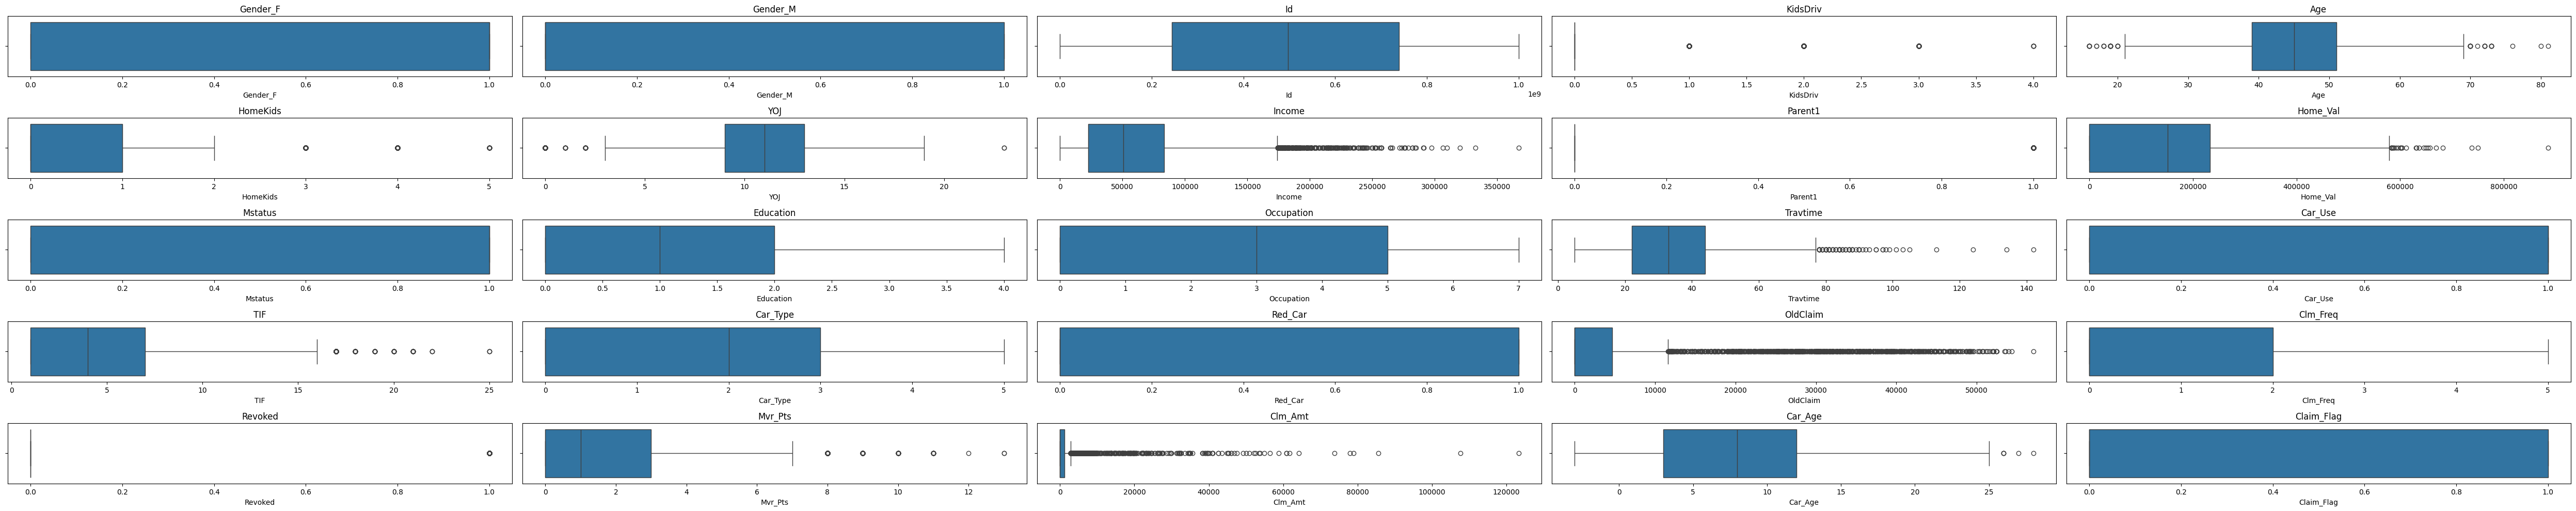

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(5, 5, figsize=(50, 10))

# Plot boxplots for each column
for i, col in enumerate(dataset.columns):
    sns.boxplot(x=dataset[col], ax=axs[i // 5, i % 5])
    axs[i // 5, i % 5].set_title(col)

plt.tight_layout()
plt.show()


In [51]:
def iqr(dataset,col):

    q1 = dataset[col].quantile(0.25)
    q3 = dataset[col].quantile(0.75)
    iqr = q3 - q1

    upper_limit = q3 + (1.5*iqr)
    lower_limit = q1 - (1.5*iqr)
    return upper_limit,lower_limit

upper1, lower1 = iqr(dataset,'Age')
print(upper1 , " ", lower1)

upper2, lower2 = iqr(dataset,'YOJ')
print(upper2 , " ", lower2)

upper3, lower3 = iqr(dataset,'Income')
print(upper3 , " ", lower3)

upper4, lower4 = iqr(dataset,'Home_Val')
print(upper4 , " ", lower4)

upper5, lower5 = iqr(dataset,'Travtime')
print(upper5 , " ", lower5)

upper6, lower6 = iqr(dataset,'OldClaim')
print(upper6 , " ", lower6)

upper7, lower7 = iqr(dataset,'Clm_Amt')
print(upper7 , " ", lower7)

upper8, lower8 = iqr(dataset,'Car_Age')
print(upper8 , " ", lower8)


69.0   21.0
19.0   3.0
174096.875   -68210.125
582712.5   -349627.5
77.0   -11.0
11618.75   -6971.25
2861.875   -1717.125
25.5   -10.5


In [52]:
# trimming -- deleting the outliers
dataset = dataset.loc[(dataset['Age'] < upper1) & (dataset['Age'] > lower1)]
dataset = dataset.loc[(dataset['YOJ'] < upper2) & (dataset['YOJ'] > lower2)]
dataset = dataset.loc[(dataset['Income'] < upper3) & (dataset['Income'] > lower3)]
dataset = dataset.loc[(dataset['Home_Val'] < upper4) & (dataset['Home_Val'] > lower4)]
dataset = dataset.loc[(dataset['Travtime'] < upper5) & (dataset['Travtime'] > lower5)]
dataset = dataset.loc[(dataset['OldClaim'] < upper6) & (dataset['OldClaim'] > lower6)]
dataset = dataset.loc[(dataset['Clm_Amt'] < upper7) & (dataset['Clm_Amt'] > lower7)]
dataset = dataset.loc[(dataset['Car_Age'] < upper8) & (dataset['Car_Age'] > lower8)]

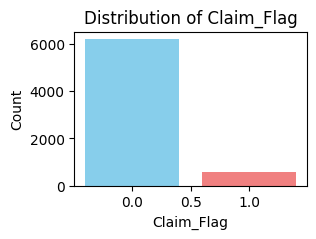

In [53]:
claim_counts = dataset['Claim_Flag'].value_counts()
# Plotting a bar plot using Matplotlib

plt.figure(figsize=(3, 2))
plt.bar(claim_counts.index, claim_counts, color=['skyblue', 'lightcoral'])
plt.title('Distribution of Claim_Flag')
plt.xlabel('Claim_Flag')
plt.ylabel('Count')
plt.show()

In [54]:
dataset['Claim_Flag'].value_counts()

Claim_Flag
0    6204
1     564
Name: count, dtype: int64

In [55]:
x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [56]:
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split  
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state=42) 


In [57]:
from sklearn.preprocessing import StandardScaler    
st_x= StandardScaler()    
x_train_scaled= st_x.fit_transform(x_train) 
x_test_scaled= st_x.transform(x_test)  

In [58]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy='minority')
X_train_sm,y_train_sm= smote.fit_resample(x_train_scaled,y_train)
X_test_sm,y_test_sm= smote.fit_resample(x_test_scaled,y_test)

In [59]:
print(y_train_sm.value_counts())
print(y_test_sm.value_counts())


Claim_Flag
1    4951
0    4951
Name: count, dtype: int64
Claim_Flag
0    1253
1    1253
Name: count, dtype: int64


In [60]:
# import matplotlib.pyplot as plt

# # Assuming df is your DataFrame
# features = dataset.columns[:-1]  # Exclude the target variable
# target = 'Claim_Flag'

# for feature in features:
#     plt.figure(figsize=(5, 2))
#     plt.scatter(dataset[feature], dataset[target], label=feature)
#     plt.xlabel(feature)
#     plt.ylabel(target)
#     plt.legend()
#     plt.show()


In [61]:
# import seaborn as sns

# correlation_matrix = dataset.corr()
# plt.figure(figsize=(20, 20))  # Set the figsize here
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
# plt.show()


In [62]:
dataset.head()

,Gender_F,Gender_M,Id,KidsDriv,Age,HomeKids,YOJ,Income,Parent1,Home_Val,Mstatus,Education,Occupation,Travtime,Car_Use,TIF,Car_Type,Red_Car,OldClaim,Clm_Freq,Revoked,Mvr_Pts,Clm_Amt,Car_Age,Claim_Flag
0,0,1,63581743,0,60,0,11,67349,0,0,0,4,6,14,1,11,0,1,4461,2,0,3,0,18,0
1,0,1,132761049,0,43,0,11,91449,0,257252,0,1,0,22,0,1,0,1,0,0,0,0,0,1,0
2,0,1,921317019,0,48,0,11,52881,0,0,0,0,5,26,1,1,5,1,0,0,0,2,0,10,0
4,0,1,450221861,0,51,0,14,0,0,306251,1,3,0,32,1,7,0,1,0,0,0,0,0,6,0
7,1,0,792300541,0,54,0,10,18755,0,0,1,3,0,33,1,1,3,0,0,0,0,0,0,1,0


In [63]:
dataset.drop(['Id','Red_Car'],axis=1).head()

,Gender_F,Gender_M,KidsDriv,Age,HomeKids,YOJ,Income,Parent1,Home_Val,Mstatus,Education,Occupation,Travtime,Car_Use,TIF,Car_Type,OldClaim,Clm_Freq,Revoked,Mvr_Pts,Clm_Amt,Car_Age,Claim_Flag
0,0,1,0,60,0,11,67349,0,0,0,4,6,14,1,11,0,4461,2,0,3,0,18,0
1,0,1,0,43,0,11,91449,0,257252,0,1,0,22,0,1,0,0,0,0,0,0,1,0
2,0,1,0,48,0,11,52881,0,0,0,0,5,26,1,1,5,0,0,0,2,0,10,0
4,0,1,0,51,0,14,0,0,306251,1,3,0,32,1,7,0,0,0,0,0,0,6,0
7,1,0,0,54,0,10,18755,0,0,1,3,0,33,1,1,3,0,0,0,0,0,1,0


In [64]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy='minority')
X_train_sm,y_train_sm= smote.fit_resample(x_train_scaled,y_train)
X_test_sm,y_test_sm= smote.fit_resample(x_test_scaled,y_test)

In [65]:
print(y_train_sm.value_counts())
print(y_test_sm.value_counts())

Claim_Flag
1    4951
0    4951
Name: count, dtype: int64
Claim_Flag
0    1253
1    1253
Name: count, dtype: int64


In [101]:
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [102]:
model = Sequential()

In [103]:
model.add(Dense(units = 3,kernel_initializer='uniform', activation='relu', input_dim=24)) 
model.add(Dense(units = 8, activation='relu'))              
model.add(Dense(units = 5, activation='relu'))            
model.add(Dense(units = 1, activation='sigmoid'))          


In [104]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 3)                 75        
                                                                 
 dense_13 (Dense)            (None, 8)                 32        
                                                                 
 dense_14 (Dense)            (None, 5)                 45        
                                                                 
 dense_15 (Dense)            (None, 1)                 6         
                                                                 
Total params: 158 (632.00 Byte)
Trainable params: 158 (632.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [105]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [106]:
print(x_train_scaled.shape)
print(y_train.shape)

(5414, 24)
(5414,)


In [107]:
# simple early stopping
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', min_delta = 0.0001, mode='auto', patience=30, verbose=1,baseline=None,restore_best_weights=False)

In [108]:
# fit model
history = model.fit(x_train_scaled, y_train, validation_data=(x_test_scaled, y_test), epochs=150, verbose=1, callbacks=[es])

Epoch 1/150


170/170 [==============================] - 2s 4ms/step - loss: 0.5017 - accuracy: 0.8999 - val_loss: 0.2728 - val_accuracy: 0.9520
Epoch 2/150
170/170 [==============================] - 0s 3ms/step - loss: 0.1515 - accuracy: 0.9813 - val_loss: 0.0569 - val_accuracy: 0.9985
Epoch 3/150
170/170 [==============================] - 1s 3ms/step - loss: 0.0409 - accuracy: 0.9948 - val_loss: 0.0225 - val_accuracy: 0.9985
Epoch 4/150
170/170 [==============================] - 1s 3ms/step - loss: 0.0200 - accuracy: 0.9970 - val_loss: 0.0119 - val_accuracy: 0.9985
Epoch 5/150
170/170 [==============================] - 0s 2ms/step - loss: 0.0126 - accuracy: 0.9982 - val_loss: 0.0078 - val_accuracy: 0.9985
Epoch 6/150
170/170 [==============================] - 0s 3ms/step - loss: 0.0089 - accuracy: 0.9985 - val_loss: 0.0059 - val_accuracy: 0.9985
Epoch 7/150
170/170 [==============================] - 0s 3ms/step - loss: 0.0069 - accuracy: 0.9987 - val_loss: 0.0042 - val_accuracy: 0.9993
Epoch 8/150

In [109]:
# evaluate the model
_, train_acc = model.evaluate(x_train_scaled, y_train, verbose=0)
_, test_acc = model.evaluate(x_test_scaled, y_test, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Train: 1.000, Test: 0.999


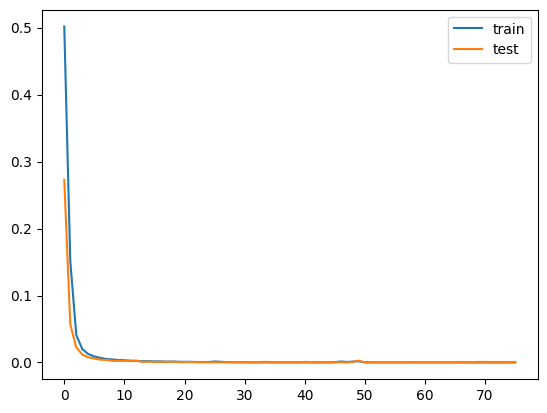

In [110]:
# plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [111]:
y_log = model.predict(x_test_scaled)
y_pred = np.where(y_log > 0.8,1,0)

43/43 [==============================] - 0s 2ms/step


In [112]:
from sklearn.metrics import accuracy_score 
accuracy_score(y_test, y_pred)

1.0

Dropout Layer Model

In [113]:
from tensorflow.keras.layers import Dropout 

In [114]:
model1 = Sequential()

In [115]:
model1.add(Dense(units = 3,kernel_initializer='uniform', activation='relu', input_dim=24)) 
model1.add(Dropout(0.3))
model1.add(Dense(units = 8, activation='relu'))  
model1.add(Dropout(0.3))            
model1.add(Dense(units = 5, activation='relu')) 
model1.add(Dropout(0.3))           
model1.add(Dense(units = 1, activation='sigmoid')) 

In [116]:
model1.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 3)                 75        
                                                                 
 dropout_3 (Dropout)         (None, 3)                 0         
                                                                 
 dense_17 (Dense)            (None, 8)                 32        
                                                                 
 dropout_4 (Dropout)         (None, 8)                 0         
                                                                 
 dense_18 (Dense)            (None, 5)                 45        
                                                                 
 dropout_5 (Dropout)         (None, 5)                 0         
                                                                 
 dense_19 (Dense)            (None, 1)                

In [117]:
from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate = 0.01)
model1.compile(loss='binary_crossentropy',optimizer=adam ,metrics=['accuracy'])

In [118]:
# fit model
history = model1.fit(x_train_scaled, y_train, validation_data=(x_test_scaled, y_test), epochs=100, verbose=1)

Epoch 1/100
170/170 [==============================] - 2s 4ms/step - loss: 0.2281 - accuracy: 0.9474 - val_loss: 0.0115 - val_accuracy: 0.9985
Epoch 2/100
170/170 [==============================] - 0s 3ms/step - loss: 0.1280 - accuracy: 0.9632 - val_loss: 0.0024 - val_accuracy: 0.9985
Epoch 3/100
170/170 [==============================] - 0s 3ms/step - loss: 0.1210 - accuracy: 0.9625 - val_loss: 0.0088 - val_accuracy: 0.9985
Epoch 4/100
170/170 [==============================] - 0s 3ms/step - loss: 0.1046 - accuracy: 0.9649 - val_loss: 0.0020 - val_accuracy: 0.9993
Epoch 5/100
170/170 [==============================] - 0s 3ms/step - loss: 0.0938 - accuracy: 0.9668 - val_loss: 0.0038 - val_accuracy: 0.9985
Epoch 6/100
170/170 [==============================] - 0s 2ms/step - loss: 0.0958 - accuracy: 0.9671 - val_loss: 0.0076 - val_accuracy: 0.9993
Epoch 7/100
170/170 [==============================] - 0s 2ms/step - loss: 0.0953 - accuracy: 0.9680 - val_loss: 0.0029 - val_accuracy: 0.9993

In [119]:
# evaluate the model
_, train_acc = model1.evaluate(x_train_scaled, y_train, verbose=0)
_, test_acc = model1.evaluate(x_test_scaled, y_test, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Train: 0.999, Test: 1.000


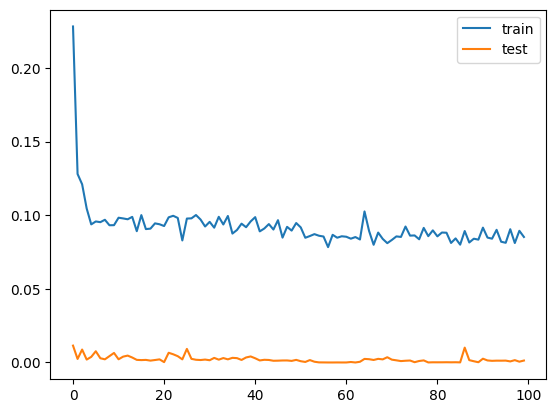

In [120]:
# plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [121]:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

Regularization : L1 and L2 

In [122]:
model2 = tf.keras.models.Sequential()

model2.add(tf.keras.layers.Dense(units=3, kernel_initializer='uniform', activation='relu', input_dim=24, kernel_regularizer=tf.keras.regularizers.l2(0.5))) 
model2.add(tf.keras.layers.Dense(units=8, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.33)))              
model2.add(tf.keras.layers.Dense(units=5, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.33)))
model.add(Dense(units = 1, activation='sigmoid')) 


In [123]:
model2.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_20 (Dense)            (None, 3)                 75        
                                                                 
 dense_21 (Dense)            (None, 8)                 32        
                                                                 
 dense_22 (Dense)            (None, 5)                 45        
                                                                 
Total params: 152 (608.00 Byte)
Trainable params: 152 (608.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [124]:
from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate = 0.01)
model2.compile(loss='binary_crossentropy',optimizer=adam ,metrics=['accuracy'])

In [125]:
# fit model
history = model2.fit(x_train_scaled, y_train, validation_data=(x_test_scaled, y_test), epochs=100, verbose=1)

Epoch 1/100
170/170 [==============================] - 2s 4ms/step - loss: 1.1538 - accuracy: 0.4913 - val_loss: 0.6197 - val_accuracy: 0.0746
Epoch 2/100
170/170 [==============================] - 0s 2ms/step - loss: 0.7046 - accuracy: 0.4967 - val_loss: 0.6206 - val_accuracy: 0.9254
Epoch 3/100
170/170 [==============================] - 0s 2ms/step - loss: 0.7036 - accuracy: 0.3279 - val_loss: 0.6227 - val_accuracy: 0.0746
Epoch 4/100
170/170 [==============================] - 0s 2ms/step - loss: 0.7035 - accuracy: 0.3958 - val_loss: 0.6208 - val_accuracy: 0.0746
Epoch 5/100
170/170 [==============================] - 1s 3ms/step - loss: 0.7042 - accuracy: 0.3823 - val_loss: 0.6195 - val_accuracy: 0.0746
Epoch 6/100
170/170 [==============================] - 0s 3ms/step - loss: 0.7042 - accuracy: 0.3419 - val_loss: 0.6204 - val_accuracy: 0.0746
Epoch 7/100
170/170 [==============================] - 0s 2ms/step - loss: 0.7036 - accuracy: 0.2728 - val_loss: 0.6240 - val_accuracy: 0.9254

In [126]:
# evaluate the model
_, train_acc = model2.evaluate(x_train_scaled, y_train, verbose=0)
_, test_acc = model2.evaluate(x_test_scaled, y_test, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))

Train: 0.914, Test: 0.925


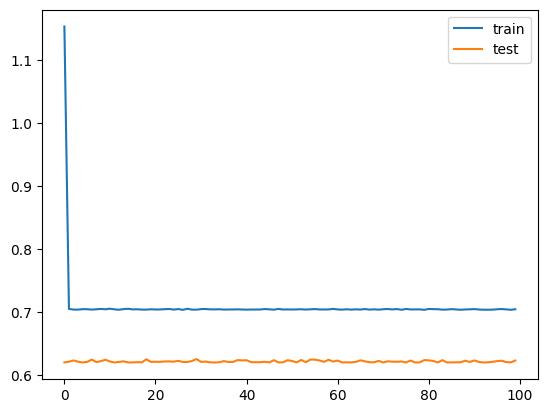

In [127]:
# plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [128]:
# from some_module import plot_decision_regions

# plot_decision_regions(x,y.astype('int'),clf=model2,legend=2)
# plt.xlim(-2,3)
# plt.ylim(-1.5,2)
# plt.show()

In [129]:
model2_weights_layer0 = model2.get_weights()[0]
print(model2_weights_layer0)

[[-9.28468704e-37 -1.20709150e-36 -1.25501098e-36]
 [-1.74131939e-37 -7.71344986e-37 -1.14519007e-36]
 [ 7.91845108e-37  1.08564910e-36  1.18258290e-36]
 [ 1.17981636e-36 -4.62417552e-37 -1.07506363e-36]
 [-8.10673538e-37 -1.73889077e-37 -1.14992104e-36]
 [ 9.97694014e-37 -1.83183834e-37 -1.59252795e-37]
 [-4.60503356e-37  7.44386963e-37 -1.07509806e-36]
 [-7.78541158e-37 -4.43998795e-37  6.66474589e-37]
 [-1.07276630e-36  1.90894428e-37  7.84013980e-37]
 [-1.13774315e-36 -7.78836754e-37  9.19068122e-37]
 [-8.93864300e-38  2.96099164e-37 -1.61306179e-37]
 [ 4.29409866e-37  1.06687592e-36 -7.74267938e-37]
 [-1.23370945e-36 -9.63634883e-37  1.19020094e-36]
 [ 9.37492618e-37  5.01637048e-37 -7.27036512e-37]
 [ 7.07822087e-37  2.05008396e-37 -8.23422887e-37]
 [-9.54702088e-37 -7.35186195e-37 -8.45820704e-37]
 [-1.25243815e-36 -4.27884039e-09  1.01284508e-36]
 [-5.87263604e-37  9.26079188e-37  8.82996861e-37]
 [ 1.04806794e-36  7.79039079e-37  1.41441013e-37]
 [ 3.93251433e-37 -4.61071588e-

In [130]:
model2_weights_layer1 = model2.get_weights()[1]
print(model2_weights_layer1)

[ 0.1964878  -0.07908367  0.16660039]


In [131]:
model2_weights_layer2 = model2.get_weights()[2]
print(model2_weights_layer2)

[[-4.45079208e-37  9.69174429e-37 -1.40688375e-36  1.84662600e-36
  -5.49673829e-37  4.45972092e-37  1.30942907e-36 -1.39674059e-36]
 [ 1.86146102e-36  1.17067693e-36  2.01768325e-37 -1.36172185e-36
   1.17146076e-36  6.20936021e-37 -1.17233033e-36 -1.25046225e-36]
 [ 3.01971972e-37 -1.03596870e-36  9.93638544e-38  1.65755358e-36
   5.75908109e-37 -5.28906630e-37  1.24208011e-36 -1.51710356e-36]]


In [132]:
print(model2_weights_layer2.min())
print(model2_weights_layer2.max())



-1.5171036e-36
1.861461e-36


In [133]:
# sns.boxplot(model2_weights)